In [50]:
import os
import sys
import pandas as pd
import numpy as np
import missingno

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [51]:
NUTS2 = 'Thessaly'

In [52]:
base_path = f'../../data/{NUTS2}/results/'

In [53]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_Thessaly_Results_2010-2022.csv',
 'GR_Thessaly_Results_2023-June-1st.csv',
 'GR_Thessaly_Results_2023-June-2nd.csv',
 'GR_Thessaly_Results_2023-May-1st.csv',
 'GR_Thessaly_Results_2023-May-2nd.csv']

In [54]:
result_files = []

for file in file_list:
    data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
    result_files.append(data)

In [55]:
concated = pd.concat(result_files, ignore_index=True, axis = 0)

In [56]:
concated.drop(columns=['case'], inplace = True)

<AxesSubplot:>

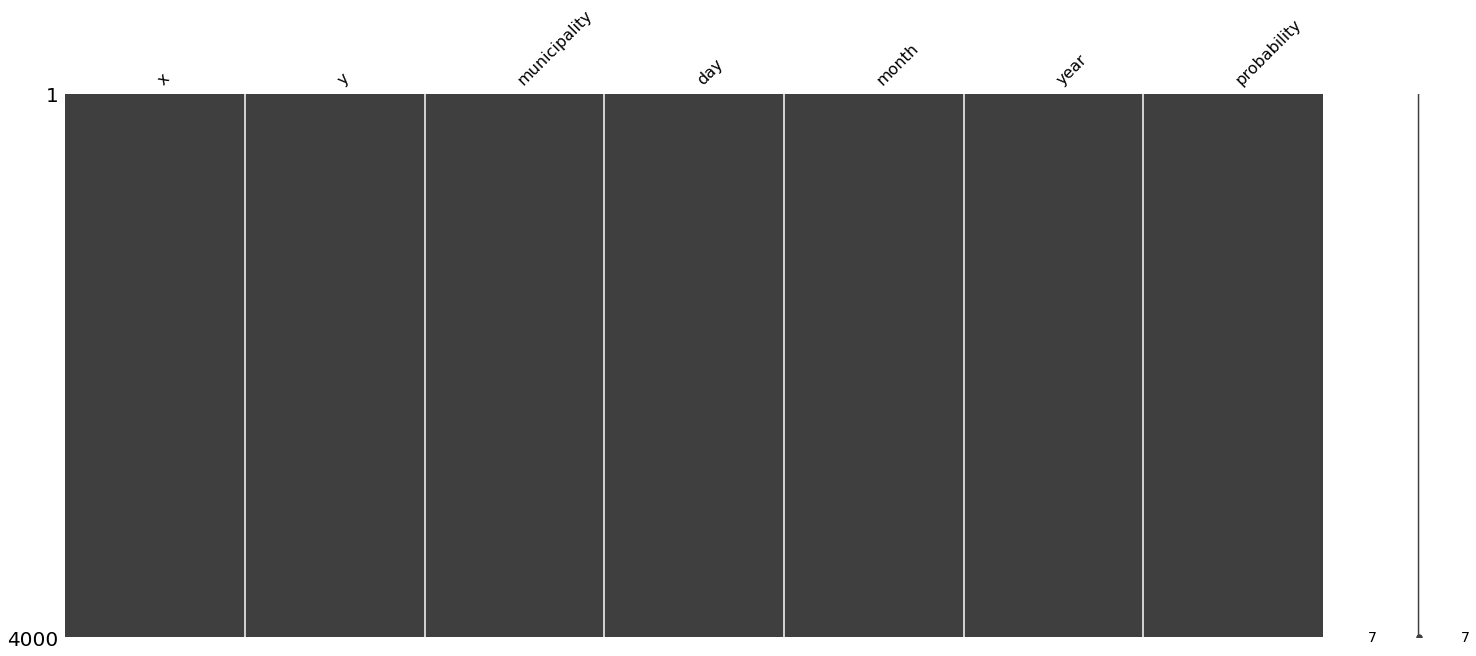

In [57]:
missingno.matrix(concated)

In [58]:
days = np.sort(concated.day.unique())
days

array([ 1, 16], dtype=int64)

In [59]:
months = np.sort(concated.month.unique())
months

array([ 5,  6,  7,  8,  9, 10], dtype=int64)

In [60]:
years = np.sort(concated.year.unique())
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023], dtype=int64)

In [61]:
df_recent = concated[(concated['year'] >= 2018) & (concated['year'] <= 2023) & (concated['month'] >= 5) & (concated['month'] <= 6)].copy()
#df_recent = df_multi_2 = concated[(concated['year'] >= 2018) & (concated['year'] <= 2023)].copy()

In [62]:
df_recent

,x,y,municipality,day,month,year,probability
424,22.25731,39.56682,λαρισαιων,16,6,2020,0.507170
482,22.25731,39.56682,λαρισαιων,16,6,2021,0.452889
725,22.08404,39.25179,σοφαδων,16,6,2020,0.273413
882,21.72537,39.29671,λιμνης πλαστηρα,16,6,2021,0.198251
994,21.72537,39.29671,λιμνης πλαστηρα,16,6,2018,0.153341
...,...,...,...,...,...,...,...
3995,22.46590,39.31130,φαρσαλων,16,5,2023,0.000113
3996,23.18165,39.23032,νοτιου πηλιου,16,5,2023,0.000063
3997,22.69237,39.13639,αλμυρου,16,5,2023,0.000024
3998,23.44531,39.15968,σκιαθου,16,5,2023,0.000015


In [63]:
df_recent.sort_values(by=['year', 'month', 'day'], ascending=True, inplace = True, ignore_index = True)

In [64]:
df_recent

,x,y,municipality,day,month,year,probability
0,21.88992,39.23076,καρδιτσας,1,5,2018,0.000266
1,21.72537,39.29671,λιμνης πλαστηρα,1,5,2018,0.000261
2,22.55316,39.85211,τεμπων,1,5,2018,0.000037
3,22.16727,39.98970,ελασσονας,1,5,2018,0.000020
4,21.95164,39.48269,παλαμα,1,5,2018,0.000010
...,...,...,...,...,...,...,...
595,22.46590,39.31130,φαρσαλων,16,6,2023,0.012967
596,23.18165,39.23032,νοτιου πηλιου,16,6,2023,0.004516
597,22.69237,39.13639,αλμυρου,16,6,2023,0.003135
598,23.44531,39.15968,σκιαθου,16,6,2023,0.001244


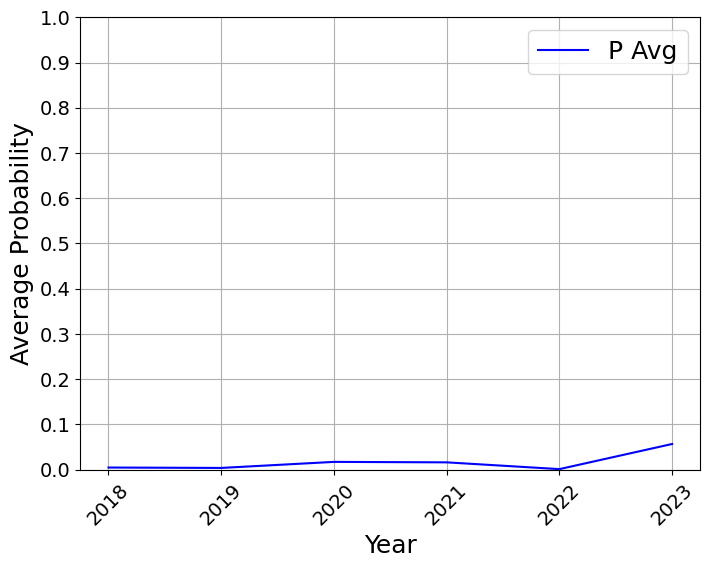

In [65]:
plot_trend_curve(df_recent, plot_cases=False)